<div style="font-family: Palatino Linotype, Palatino, serif; border-bottom: 3px solid #B85300; padding-bottom: 14px; margin-bottom: 6px;">
<h1 style="color: #B85300; margin-bottom: 4px; letter-spacing: 0.5px;">Analisis de Clustering &mdash; Palmer Penguins</h1>
<p style="color: #3B2412; font-size: 15px; margin-top: 0;">Dataset cientifico / biologico &mdash; K-Means y Clustering Jerarquico Aglomerativo</p>
<p style="color: #3B2412; font-size: 13px; opacity: 0.75; margin-top: 2px;">Mineria de Datos / Aprendizaje Automatico</p>
</div>

<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">1. Configuracion Inicial</h2>
</div>

In [4]:
import sys
sys.path.append("../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts import preprocessing, clustering, visualization, style

style.set_plot_style()

NOMBRE_DATASET = "Palmer Penguins"


<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">2. Seleccion y Carga de Datos</h2>
</div>

In [5]:
DATA_PATH = "../data/dataset2_penguins/penguins.csv"

df = preprocessing.load_data(DATA_PATH)
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [6]:
preprocessing.explore_data(df)


Dimensiones: 344 filas x 8 columnas

Tipos de datos:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object 

Valores nulos por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64 

Estadisticas descriptivas:
                   count unique     top freq         mean         std     min  \
species              344      3  Adelie  152          NaN         NaN     NaN   
island               344      3  Biscoe  168          NaN         NaN     NaN   
bill_length_mm     342.0    NaN     NaN  NaN     43.92193    5.459584    32.1   
bill_depth_mm      342.0    NaN     NaN  NaN     17.15117    1.974793    13.1   
flipper_length_mm  342.0    NaN  

<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">3. Preprocesamiento de Datos</h2>
</div>

<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">3.1 Manejo de valores nulos / atipicos</h3>

In [7]:
# Palmer Penguins SI trae nulos en variables numericas y en sex
df_limpio = preprocessing.handle_missing_values(df, strategy="drop")

# Revision de outliers en las medidas fisicas
df_limpio = preprocessing.handle_outliers(
    df_limpio,
    columns=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
)

print(f"Filas originales: {len(df)} -> Filas despues de limpieza: {len(df_limpio)}")


Filas originales: 344 -> Filas despues de limpieza: 333


<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">3.2 Seleccion de variables numericas</h3>

In [8]:
# TODO: definir la lista de columnas numericas relevantes para el clustering
COLUMNAS_NUMERICAS = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

X = preprocessing.select_numeric_features(df_limpio, COLUMNAS_NUMERICAS)


<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">3.3 Normalizacion / Estandarizacion</h3>

<div style="font-family: Palatino Linotype, Palatino, serif; background-color: #FDE8E8; border-left: 4px solid #B83A3A; padding: 10px 16px; margin: 12px 0; border-radius: 3px;">
<p style="color: #3B2412; margin: 0; font-size: 14px;">&#9888; Obligatorio: sin este paso, variables con escalas distintas sesgan el calculo de distancias.</p>
</div>

In [9]:
X_scaled, scaler = preprocessing.scale_features(X, method="standard")


<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">4. Determinacion del Numero Optimo de Clusters (K)</h2>
</div>

<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">Metodo del Codo de Jambu</h3>

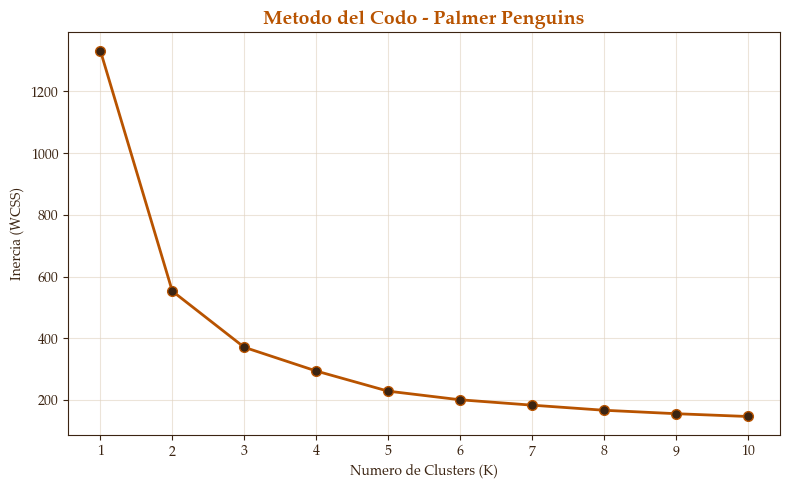

In [10]:
K_RANGE = range(1, 11)
inertias = clustering.elbow_method(X_scaled, k_range=K_RANGE)

visualization.plot_elbow(inertias, K_RANGE, title=f"Metodo del Codo - {NOMBRE_DATASET}")


In [11]:
K_OPTIMO = 3  # el dataset tiene 3 especies conocidas; confirmar que el codo lo respalde


<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">5. Aplicacion de Algoritmos</h2>
</div>

<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">5.1 K-Means</h3>

In [12]:
labels_kmeans, modelo_kmeans = clustering.kmeans_clustering(X_scaled, n_clusters=K_OPTIMO)


<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">5.2 Clustering Jerarquico Aglomerativo</h3>

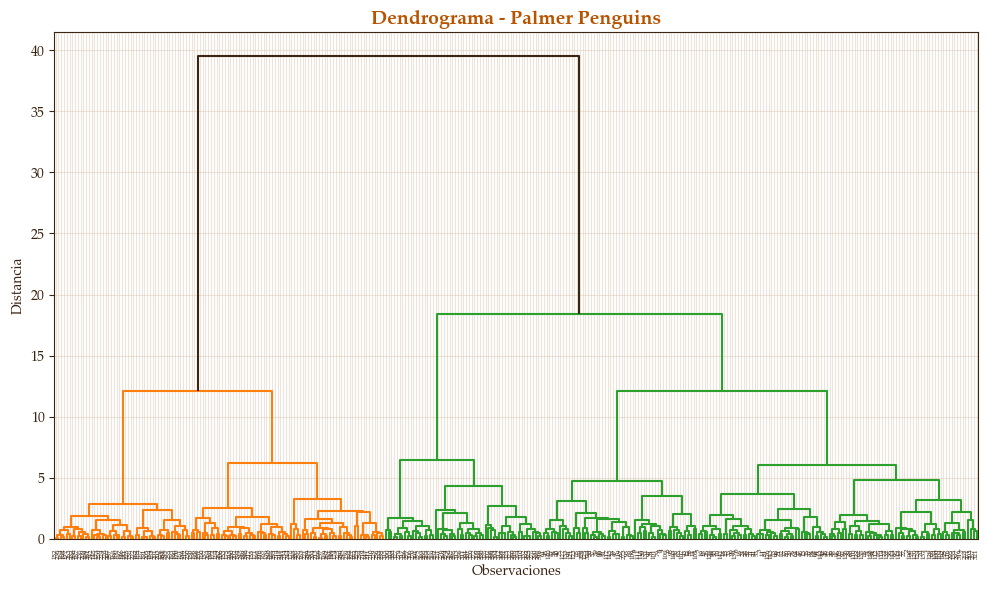

In [13]:
LINKAGE_METODO = "ward"  # Ward minimiza la varianza intra-cluster; funciona bien con variables escaladas

labels_jerarquico = clustering.hierarchical_clustering(X_scaled, n_clusters=K_OPTIMO, linkage=LINKAGE_METODO)

Z = clustering.linkage_matrix(X_scaled, method=LINKAGE_METODO)
visualization.plot_dendrogram(Z, title=f"Dendrograma - {NOMBRE_DATASET}")


<div style="font-family: Palatino Linotype, Palatino, serif; border-left: 5px solid #B85300; padding: 4px 0 4px 14px; margin-top: 30px;">
<h2 style="color: #B85300; margin: 0;">6. Analisis y Conclusiones Visuales</h2>
</div>

<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">6.1 Reduccion de dimensionalidad (PCA)</h3>

In [14]:
X_pca, varianza_explicada = clustering.apply_pca(X_scaled, n_components=2)
print("Varianza explicada por componente:", varianza_explicada)


Varianza explicada por componente: [0.68633893 0.19452929]


<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">6.2 Visualizacion de clusters</h3>

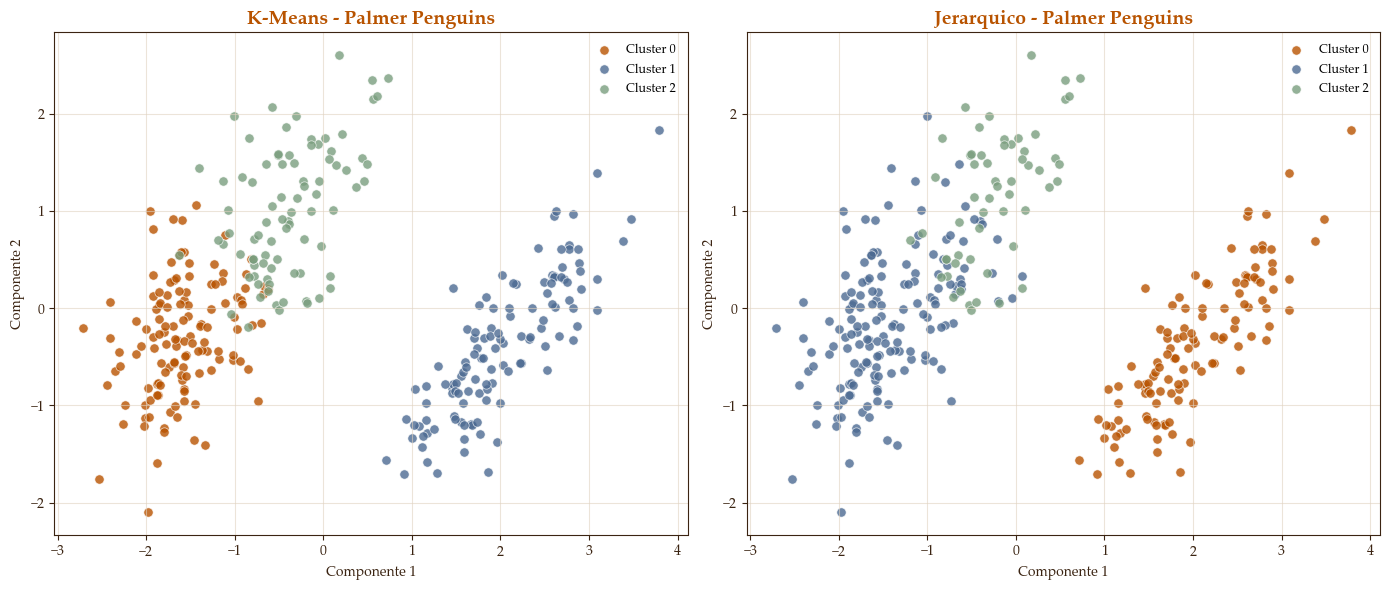

In [15]:
visualization.plot_comparison(X_pca, labels_kmeans, labels_jerarquico, dataset_name=NOMBRE_DATASET)


<h3 style="font-family: Palatino Linotype, Palatino, serif; color: #3B2412; border-bottom: 1px solid #B85300; display: inline-block; padding-bottom: 2px; margin-top: 20px;">6.3 Interpretacion de los clusters</h3>

<div style="font-family: Palatino Linotype, Palatino, serif; color: #020100; font-size: 14px; line-height: 1.6;">
<p><strong>Cluster 0 (n=129):</strong> Pico corto y delgado (38.3mm / 18.1mm), masa corporal baja (3593.8g). Coincide en un 96% con la especie <em>Adelie</em> (124 de 129 individuos), confirmando que el algoritmo aisló casi perfectamente este grupo sin conocer la etiqueta real.</p>
<p><strong>Cluster 1 (n=119):</strong> Pico largo (47.6mm), aleta larga y masa corporal notablemente mayor (5092.4g). Coincide en 100% con la especie <em>Gentoo</em> — el cluster más "limpio" de los tres, ya que esta especie es morfológicamente muy distinta a las otras dos.</p>
<p><strong>Cluster 2 (n=85):</strong> Pico largo y profundo (47.7mm / 18.7mm), masa corporal intermedia (3898.2g). Es una mezcla de <em>Chinstrap</em> (63) y <em>Adelie</em> (22): el algoritmo confunde parte de estas dos especies porque comparten medidas de pico similares, y solo logra separarlas parcialmente usando profundidad de pico y masa corporal.</p>
<p><strong>Conclusión general:</strong> K-Means, sin conocer la especie, reconstruyó las agrupaciones biológicas reales con alta fidelidad (Gentoo 100%, Adelie 96%). El único punto débil es la superposición morfológica entre Adelie y Chinstrap, esperable dado que ambas comparten hábitat y tamaño corporal similar.</p>
</div>